# Redes Neuronales Recurrentes — Modelos de Forecasting

**Objetivo:** Entrenar modelos de redes neuronales recurrentes (LSTM/GRU) para predecir el promedio 
del log-return de cierre futuro de 23 activos del S&P 500, a través de 16 combinaciones de ventanas 
temporales de entrada y salida.

**Métrica:** MAE (Mean Absolute Error)

In [11]:
import sys
sys.path.append('..')
os.chdir('..')

## 1. Imports y configuración

Se importan las librerías de deep learning (TensorFlow/Keras) junto con la infraestructura 
compartida del proyecto (`src/`), que garantiza que todos los miembros del equipo usen el 
mismo pipeline de datos, métricas de evaluación y formato de almacenamiento de resultados.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, History

# Infraestructura compartida del proyecto
from src.data_pipeline import load_data, get_train_test
from src.evaluation import compute_mae, save_results, count_parameters
from src.plotting import plot_training_curves
from config import INPUT_WINDOWS, OUTPUT_WINDOWS, FIGURES_DIR, MODELS_DIR

import os
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## 2. Carga de datos

Se utiliza la función compartida `load_data()` que replica exactamente el pipeline del profesor:
descarga los precios de cierre de 23 tickers del S&P 500, calcula log-returns diarios y devuelve 
un DataFrame de shape ~(16192, 23).

In [13]:
returns = load_data()
print(f"\nShape: {returns.shape}")
print(f"Columnas: {list(returns.columns)}")
returns.head()

[*********************100%***********************]  23 of 23 completed

Datos cargados: 16193 días, 23 activos
Rango: 1962-01-03 → 2026-05-06

Shape: (16193, 23)
Columnas: ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


Ticker,AEP,BA,CAT,CNP,CVX,DIS,DTE,ED,GD,GE,...,IP,JNJ,KO,KR,MMM,MO,MRK,MSI,PG,XOM
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,-0.001823,0.019802,0.009693,-0.009819,-0.002260,0.013332,-0.008264,0.000000,0.032925,-0.010085,...,-0.013746,-0.015669,-0.022532,0.020791,0.007491,-0.018518,-0.042802,-0.002911,-0.010989,0.014743
1962-01-04,-0.014707,-0.009852,0.025398,0.000000,-0.009092,0.000000,-0.008333,-0.003091,0.004040,-0.011894,...,-0.003467,-0.010578,0.007569,-0.004124,0.000000,0.006985,-0.010255,-0.008784,-0.016714,0.002436
1962-01-05,-0.022472,-0.020000,0.009361,-0.024419,-0.025434,0.003309,-0.021143,-0.021911,0.004025,-0.025975,...,0.010364,-0.016090,-0.022875,-0.025106,-0.026467,0.011533,-0.034463,-0.005900,-0.007047,-0.022141
1962-01-08,-0.007606,0.002521,0.006192,-0.011300,-0.004695,-0.003309,0.002135,0.004736,0.015936,-0.001757,...,-0.020834,-0.016349,-0.010335,-0.004246,-0.005764,-0.006904,0.003044,-0.017912,-0.027242,-0.002491
1962-01-09,-0.007662,0.002516,0.009216,0.000000,0.014020,0.019677,0.002129,-0.001576,0.003944,0.005259,...,-0.014134,0.010930,0.018017,-0.021506,0.000000,-0.018648,0.004549,-0.024391,-0.001455,-0.002496


## 3. Entrenamiento del modelo — Entrada=5, Salida=1

Comenzamos con la combinación de ventanas más sencilla (5 días de historia → predecir 1 día 
a futuro) para establecer un baseline de arquitectura recurrente. Esto permite validar el 
pipeline completo (datos → modelo → evaluación → almacenamiento) antes de escalar a 
configuraciones más complejas.

### 3.1 Preparación de datos

In [14]:
# Configuración de ventanas para este primer modelo
INPUT_W = 5
OUTPUT_W = 1

# Generar datos con ventanas y split (90% train / 10% test, cronológico)
X_train, X_test, y_train, y_test = get_train_test(returns, INPUT_W, OUTPUT_W)

print(f"\nInput shape:  X_train {X_train.shape} → (muestras, timesteps={INPUT_W}, activos=23)")
print(f"Output shape: y_train {y_train.shape} → (muestras, activos=23)")

Ventana entrada=5, salida=1
  X_train: (14569, 5, 23) | y_train: (14569, 23)
  X_test:  (1619, 5, 23)  | y_test:  (1619, 23)

Input shape:  X_train (14569, 5, 23) → (muestras, timesteps=5, activos=23)
Output shape: y_train (14569, 23) → (muestras, activos=23)


### 3.2 Arquitectura del modelo — LSTM v1

**Justificación del diseño del primer modelo:**

Se elige una arquitectura deliberadamente simple para establecer un baseline recurrente:

- **Capa LSTM (64 unidades):** Long Short-Term Memory captura dependencias temporales en la 
  ventana de entrada de 5 días. 64 unidades proporcionan capacidad suficiente sin riesgo excesivo 
  de overfitting para esta ventana de entrada corta. Se usa `return_sequences=False` ya que solo 
  necesitamos el estado oculto final como entrada a la capa densa.

- **Capa Dense de salida (23 unidades, activación lineal):** Una salida por activo. La activación 
  lineal es apropiada porque se predicen valores continuos (promedio de log-returns), no 
  clasificaciones. El modelo predice los 23 activos simultáneamente, aprovechando cualquier 
  patrón cross-asset aprendido por la LSTM.

- **Función de pérdida: MAE** — especificada por el enunciado. Es también la métrica utilizada 
  para el ranking de la competición.

- **Optimizador: Adam (lr=0.001)** — learning rate por defecto. Se comienza aquí y se ajusta 
  si es necesario.

- **EarlyStopping (patience=10):** Monitoriza la loss de validación para detener el entrenamiento 
  cuando el modelo deja de mejorar, previniendo overfitting y asegurando convergencia.

- **Sin regularización (dropout, L2)** en esta primera versión — se añade si se observa 
  overfitting en las curvas de entrenamiento.

In [15]:
def build_lstm_v1(input_window, n_assets=23):
    """
    Modelo LSTM simple para forecasting multi-activo.
    
    Arquitectura: LSTM(64) → Dense(23)
    
    Parameters
    ----------
    input_window : int
        Número de timesteps en la secuencia de entrada.
    n_assets : int
        Número de activos (canales) = 23.
    
    Returns
    -------
    keras.Model
        Modelo compilado listo para entrenar.
    """
    model = keras.Sequential([
        layers.LSTM(64, input_shape=(input_window, n_assets)),
        layers.Dense(n_assets)  # Activación lineal para regresión
    ])
    
    model.compile(
        optimizer='adam',
        loss='mae'
    )
    
    return model

# Construir e inspeccionar el modelo
model = build_lstm_v1(INPUT_W)
model.summary()

/Users/eduardogonzalezarroyo/Desktop/Material MIAX/Prácticas Entregables/Redes Neuronales para Forecasting/neural-network-forecasting/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Entrenamiento

Se entrena con `validation_split=0.1`, que toma el último 10% del conjunto de entrenamiento 
como validación (split cronológico, sin shuffle). EarlyStopping monitoriza la loss de validación 
y restaura los mejores pesos automáticamente.

In [16]:
# Configuración del entrenamiento
BATCH_SIZE = 64
EPOCHS = 100
VAL_SPLIT = 0.1

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nEntrenamiento detenido en la época {len(history.history['loss'])}")

Epoch 1/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0120 - val_loss: 0.0091
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - loss: 0.0119 - val_loss: 0.0091
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 0.0119 - val_loss: 0.0091
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - loss: 0.0119 - val_loss: 0.0091
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - loss: 0.0119 - val_loss: 0.0091
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 0.0118 - val_loss: 0.0091
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 955us/step - loss: 0.0118 - val_loss: 0.0091
Epoch 9/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step - loss: 0.0118 - val_loss: 0.0091
Epoch 10/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step - loss: 0.0118 - val_loss: 0.0091
Epoch 11/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - loss: 0.0118 - val_loss: 0.0091
Epoch 12/100
205/205 ━━

### 3.4 Curvas de convergencia

El enunciado exige curvas de entrenamiento para cada modelo donde se vea que ha convergido. 
Se utiliza la función compartida `plot_training_curves()` para garantizar un formato 
consistente entre todos los miembros del equipo.

Gráfica guardada: convergence_LSTM_v1_in5_out1.png


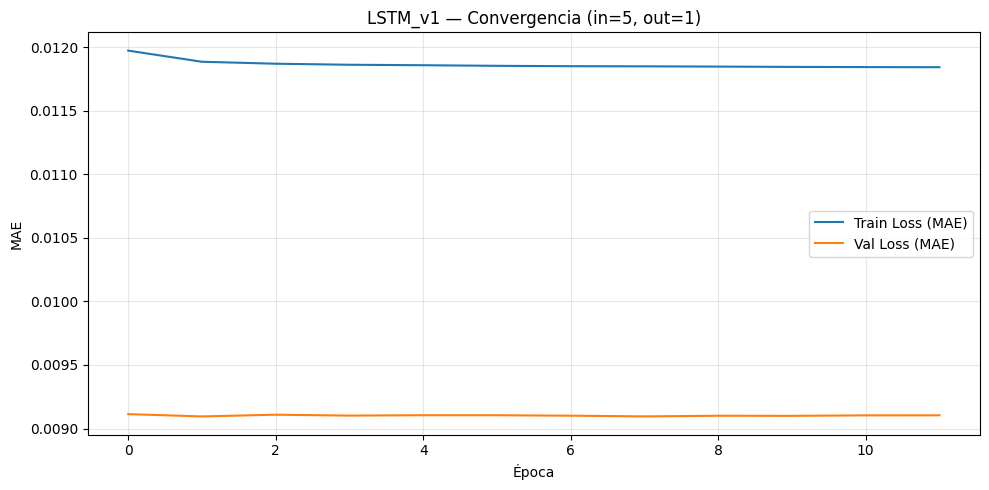

In [17]:
# Curvas de convergencia (se guardan automáticamente en results/figures/)
plot_training_curves(history, model_name="LSTM_v1", input_window=INPUT_W, output_window=OUTPUT_W)

### 3.5 Evaluación

Se calcula el MAE sobre los conjuntos de entrenamiento, validación y test. El MAE en test 
es la métrica utilizada para el ranking de la competición.

In [18]:
# --- Predicciones ---
y_pred_train = model.predict(X_train, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

# Para validación: extraer el mismo último 10% que Keras usó durante el entrenamiento
val_size = int(len(X_train) * VAL_SPLIT)
X_val = X_train[-val_size:]
y_val = y_train[-val_size:]
y_pred_val = model.predict(X_val, verbose=0)

# --- Cálculo de MAE ---
mae_train = compute_mae(y_train, y_pred_train)
mae_val = compute_mae(y_val, y_pred_val)
mae_test = compute_mae(y_test, y_pred_test)

print(f"MAE Train:      {mae_train:.6f}")
print(f"MAE Validation: {mae_val:.6f}")
print(f"MAE Test:       {mae_test:.6f}")
print(f"Parámetros:     {count_parameters(model):,}")

MAE Train:      0.011584
MAE Validation: 0.009097
MAE Test:       0.012322
Parámetros:     24,023


### 3.6 Guardar resultados

Los resultados se guardan en el CSV compartido (`results/tables/all_results.csv`) para que 
todos los miembros del equipo puedan acceder a ellos. Los pesos del modelo se guardan en 
`models/` para reproducibilidad.

In [21]:
# Guardar métricas en el CSV compartido
save_results(
    model_name="LSTM_v1",
    model_type="recurrent",
    input_window=INPUT_W,
    output_window=OUTPUT_W,
    mae_train=mae_train,
    mae_test=mae_test,
    n_params=count_parameters(model),
    mae_val=mae_val
)

# Guardar pesos del modelo
model_path = os.path.join(MODELS_DIR, f"LSTM_v1_in{INPUT_W}_out{OUTPUT_W}.keras")
model.save(model_path)
print(f"Modelo guardado: {model_path}")

Resultados guardados: LSTM_v1 | in=5 out=1 | MAE test=0.012322
Modelo guardado: models/LSTM_v1_in5_out1.keras
